In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.layers import (Input, Dense, Flatten, Reshape, Rescaling, InputLayer, Dropout,
                            Convolution2D, MaxPooling2D, RandomRotation, RandomFlip
                            , RandomCrop, ZeroPadding2D, RandomErasing
                            )

from keras.datasets import cifar10

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [3]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [ ]:
def plot_sample(X: np.array, y: np.array, labels=None) -> None:
    idxs = np.random.randint(0, X.shape[0], 12)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 4, i+1)
        if labels:
            plt.title(labels[y[idx]])
        else:
            plt.title(y[idx])
        plt.imshow(X[idx], cmap='gray')
    plt.tight_layout()
    plt.show()


def get_preprocessor() -> keras.Sequential:
    preprocessor = keras.Sequential([
        RandomFlip('horizontal')
        , ZeroPadding2D(4)
        , RandomCrop(32, 32)
        , RandomErasing(factor=0.2, scale=(0.02, 0.2))

        , Rescaling(1./255)
    ])

    return preprocessor

def get_cnn(n_class, activation: str = 'relu') -> keras.Sequential:

    preprocessor = get_preprocessor()

    model = keras.Sequential([
        Input((32, 32, 3))

        , preprocessor

        , Convolution2D(64, 3, activation='relu', padding='same')
        , Convolution2D(64, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , Convolution2D(128, 3, activation='relu', padding='same')
        , Convolution2D(128, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , Convolution2D(256, 3, activation='relu', padding='same')
        , Convolution2D(256, 3, activation='relu', padding='same')
        , MaxPooling2D(2)

        , GlobalAveragePooling2D()

        , Dense(10, activation='softmax')

    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [18]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape)
print(y_train.shape)

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

labels = 'airplane automobile bird cat deer dog frog horse ship truck'

labels = labels.split(' ')

# plot_sample(X_train, y_train, labels)

(50000, 32, 32, 3)
(50000, 1)


In [19]:
cnn = get_cnn(10)
cnn.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (None, 32, 32, 3)         0         
                                                                 
 conv2d_9 (Conv2D)           (None, 32, 32, 64)        3136      
                                                                 
 dropout_10 (Dropout)        (None, 32, 32, 64)        0         
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 16, 16, 128)       131200    
                                                                 
 dropout_11 (Dropout)        (None, 16, 16, 128)       0         
                                                      

# Résultats

Cifar10 est un dataset où il faut absolument prévenir l'overfitting. Il est tout a fait possible d'atteindre 100% d'accuracy sur le train set mais avec un validation set restant à 70%.

Plusieurs solutions pour prévenir cet overfitting:
1. Utiliser de la data augmentation. C'est à dire appliquer à chaque epoch de légères modifications (tourner, inverser haute/bas, droite/gauche, zoomer, croper, *etc*.) à votre images. Cela a pour effet d'augmenter artificiellement la diversité/variance de votre jeu de données.
w
2. Utiliser des couches de dropout, qui à chaque step masquent une partie des neurones (ils ne participent pas au forward pass, n'apportent pas de gradients). Cela a pour effet d'empêcher le réseau de trop s'adapter aux données d'entrainement, d'avoir des neuronnes trop spécialisés.

3. Adapter le learning rate.

4. Jouer avec la taille du kernel (*i.e.* l'augmenter) et le stride.

5. Utiliser la batch normalization à la place des couches de dropout.

6. Régulariser (l1/l2)

In [20]:
cnn.fit(X_train, y_train, validation_split=.2, epochs=50, batch_size=1024)

Epoch 1/50
40/40 [==============================] - 3s 55ms/step - loss: 2.1869 - accuracy: 0.1688 - val_loss: 2.0197 - val_accuracy: 0.2398
Epoch 2/50
40/40 [==============================] - 2s 48ms/step - loss: 1.9212 - accuracy: 0.2670 - val_loss: 1.8006 - val_accuracy: 0.3343
Epoch 3/50
40/40 [==============================] - 2s 48ms/step - loss: 1.7202 - accuracy: 0.3553 - val_loss: 1.6360 - val_accuracy: 0.4021
Epoch 4/50
40/40 [==============================] - 2s 48ms/step - loss: 1.6056 - accuracy: 0.4046 - val_loss: 1.5220 - val_accuracy: 0.4529
Epoch 5/50
40/40 [==============================] - 2s 48ms/step - loss: 1.5138 - accuracy: 0.4424 - val_loss: 1.6127 - val_accuracy: 0.4069
Epoch 6/50
40/40 [==============================] - 2s 48ms/step - loss: 1.4938 - accuracy: 0.4541 - val_loss: 1.4059 - val_accuracy: 0.4782
Epoch 7/50
40/40 [==============================] - 2s 48ms/step - loss: 1.3738 - accuracy: 0.5011 - val_loss: 1.4681 - val_accuracy: 0.4674
Epoch 8/50
40

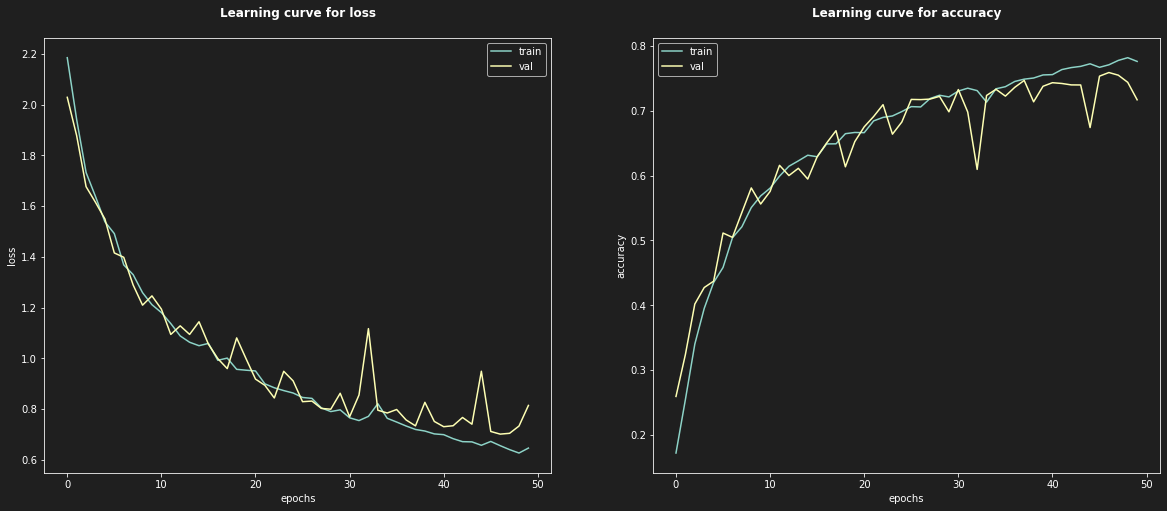

In [10]:
plot_lc(cnn.history.history)